In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load cleaned dataset

df = pd.read_csv("../processed/cleaned_youtube_data.csv")

df.head()

,video_duration_min,avg_view_duration_sec,avg_view_percentage,subscribers_gained,traffic_source,ctr_percentage,impressions,likes,comments,shares,total_watch_time_hours,content_category
0,45.55,2422,88.62,564,Shorts Feed,28.70,1975899,88186,1055,63,1329340.94,Sports
1,59.12,562,15.84,523,Notifications,25.67,1552915,69884,5883,131,242427.29,Vlog
2,40.06,2369,98.56,628,External,10.13,90886,37931,3746,2555,59808.04,News
3,42.54,2097,82.16,239,External,25.00,999294,38861,1575,900,582088.76,Education
4,31.40,1424,75.58,138,Shorts Feed,23.49,1656171,57043,3150,1452,655107.64,Sports


In [3]:
# Independent variable (Feature)

X = df[["video_duration_min"]]

# Dependent variable (Target)

y = df["avg_view_percentage"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (29999, 1)
Target Shape : (29999,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 23999
Testing Samples : 6000


In [5]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [6]:
print("Slope (Coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)

Slope (Coefficient): -0.0029970401681622873
Intercept: 50.37800667570732


In [7]:
y_pred = model.predict(X_test)

y_pred[:10]

array([50.23882413, 50.24397904, 50.34509917, 50.36191257, 50.35747695,
       50.36541911, 50.22464813, 50.26681649, 50.29292071, 50.25404909])

In [8]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R² Score :", r2)

Mean Absolute Error : 24.944908806388053
Mean Squared Error : 828.5148866037634
Root Mean Squared Error : 28.783934522642372
R² Score : -5.8089889292789465e-05


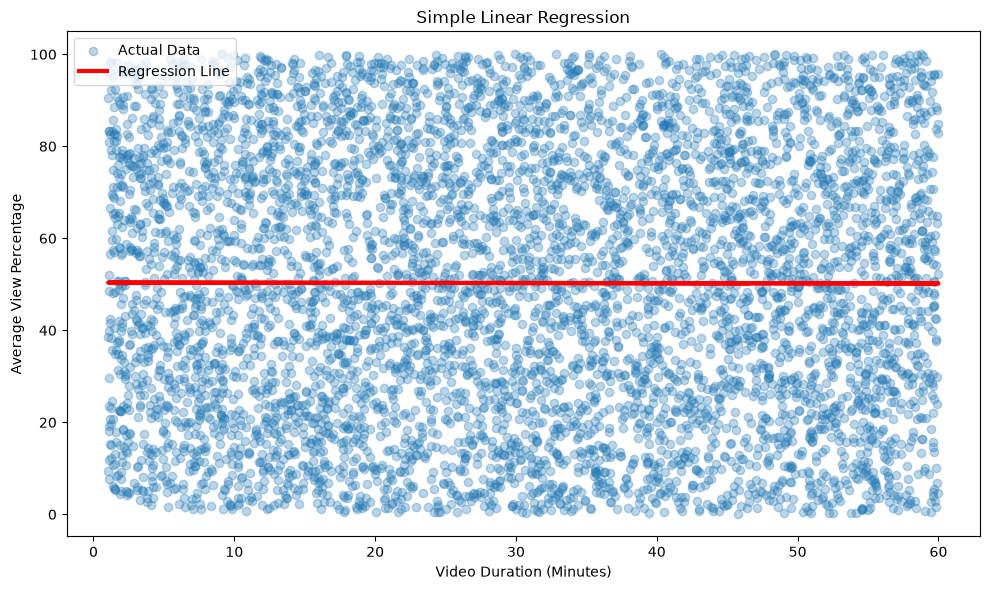

In [9]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_test,
    y_test,
    alpha=0.3,
    label="Actual Data"
)

plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.title("Simple Linear Regression")

plt.xlabel("Video Duration (Minutes)")
plt.ylabel("Average View Percentage")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/simple_linear_regression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,81.25,50.238824
1,30.41,50.243979
2,5.31,50.345099
3,65.80,50.361913
4,84.43,50.357477
5,42.06,50.365419
6,80.45,50.224648
7,51.62,50.266816
8,32.64,50.292921
9,3.79,50.254049


In [12]:
import os
import joblib

# Create the models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the model
joblib.dump(model, "../models/simple_linear_regression.pkl")

print("Model saved successfully.")

Model saved successfully.


# Conclusion

A Simple Linear Regression model was trained using **Video Duration** as the only predictor for **Average View Percentage**.

### Model Performance

- Mean Absolute Error (MAE): 24.94
- Root Mean Squared Error (RMSE): 28.78
- R² Score: -0.000058

### Interpretation

The model achieved an R² score close to zero, indicating that **Video Duration alone is not a useful predictor of Average View Percentage** for this dataset.

This result is consistent with the Exploratory Data Analysis, where the correlation between Video Duration and Average View Percentage was nearly zero.

Therefore, a more complex model using additional features (Multiple Linear Regression) will be explored in the next notebook.